In [ ]:
pip install pyod matplotlib pandas numpy

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD

pollutants = ['CH4', 'CO', 'NO2', 'SO2']

BULAN_MAP = {
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 
    7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
}

summary_dynamic = []

for pol in pollutants:
    # 1. Load Data
    file_path = f"{pol}_lamongan_missing.csv"
    if not os.path.exists(file_path):
        file_path = f"data/{pol}_lamongan_missing.csv"
    
    df_p = pd.read_csv(file_path)
    df_p['date'] = pd.to_datetime(df_p['date'])
    df_valid = df_p.dropna(subset=[pol]).copy()
    
    # 2. Standarisasi Data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_valid[[pol]].values)
    
    # 3. Model PyOD
    models = {
        'KNN': KNN(n_neighbors=5),
        'Isolation Forest': IForest(random_state=42),
        'ECOD': ECOD()
    }
    
    print("=" * 75)
    print(f"       DETEKSI OUTLIER DINAMIS (PyOD Anomaly Score) — {pol}")
    print("=" * 75)
    print(f"Total Data Valid: {len(df_valid)} hari\n")
    
    for name, model in models.items():
        # Training model tanpa memaksakan fixed contamination
        model.fit(X_scaled)
        
        # Ambil skor anomali kontinu (semakin tinggi = semakin anomali)
        scores = model.decision_scores_
        
        # Threshold Dinamis: Nilai yang berada di luar mean + 2.5 * std deviasi skor anomali
        dynamic_threshold = scores.mean() + (2.5 * scores.std())
        
        # Penentuan outlier secara dinamis
        is_outlier = scores > dynamic_threshold
        df_valid[f'outlier_{name}'] = is_outlier.astype(int)
        
        outliers_m = df_valid[df_valid[f'outlier_{name}'] == 1]
        persen = (len(outliers_m) / len(df_valid)) * 100
        
        summary_dynamic.append({
            "Polutan": pol,
            "Metode": name,
            "Total Data": len(df_valid),
            "Jumlah Outlier": len(outliers_m),
            "Persentase": f"{persen:.2f}%",
            "Threshold Skor": f"{dynamic_threshold:.4f}"
        })
        
        print(f">>> Metode: {name:<18} | Jumlah Outlier: {len(outliers_m)} hari ({persen:.2f}%)")
        if len(outliers_m) > 0:
            for idx, row in outliers_m.iterrows():
                dt = row['date']
                score_val = scores[df_valid.index.get_loc(idx)]
                print(f"    • {dt.day:>2} {BULAN_MAP[dt.month]:<9} {dt.year} | Nilai: {row[pol]:.6g} (Skor Anomali: {score_val:.3f})")
        else:
            print("    (Tidak ditemukan data anomali ekstrem)")
        print()



       DETEKSI OUTLIER DINAMIS (PyOD Anomaly Score) — CH4
Total Data Valid: 366 hari

>>> Metode: KNN                | Jumlah Outlier: 5 hari (1.37%)
    • 24 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)
    • 25 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)
    • 26 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)
    • 27 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)
    • 28 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)

>>> Metode: Isolation Forest   | Jumlah Outlier: 16 hari (4.37%)
    •  7 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    •  8 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    •  9 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    • 10 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    • 22 Juni      2026 | Nilai: 1879.98 (Skor Anomali: 0.143)
    • 23 Juni      2026 | Nilai: 1879.98 (Skor Anomali: 0.143)
    • 24 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 25 Juni      2026 | Ni

c:\Users\ASUS\anaconda3\Lib\site-packages\pyod\models\sos.py:206: RuntimeWarning: overflow encountered in multiply
  beta[i] = beta[i] * 2.0


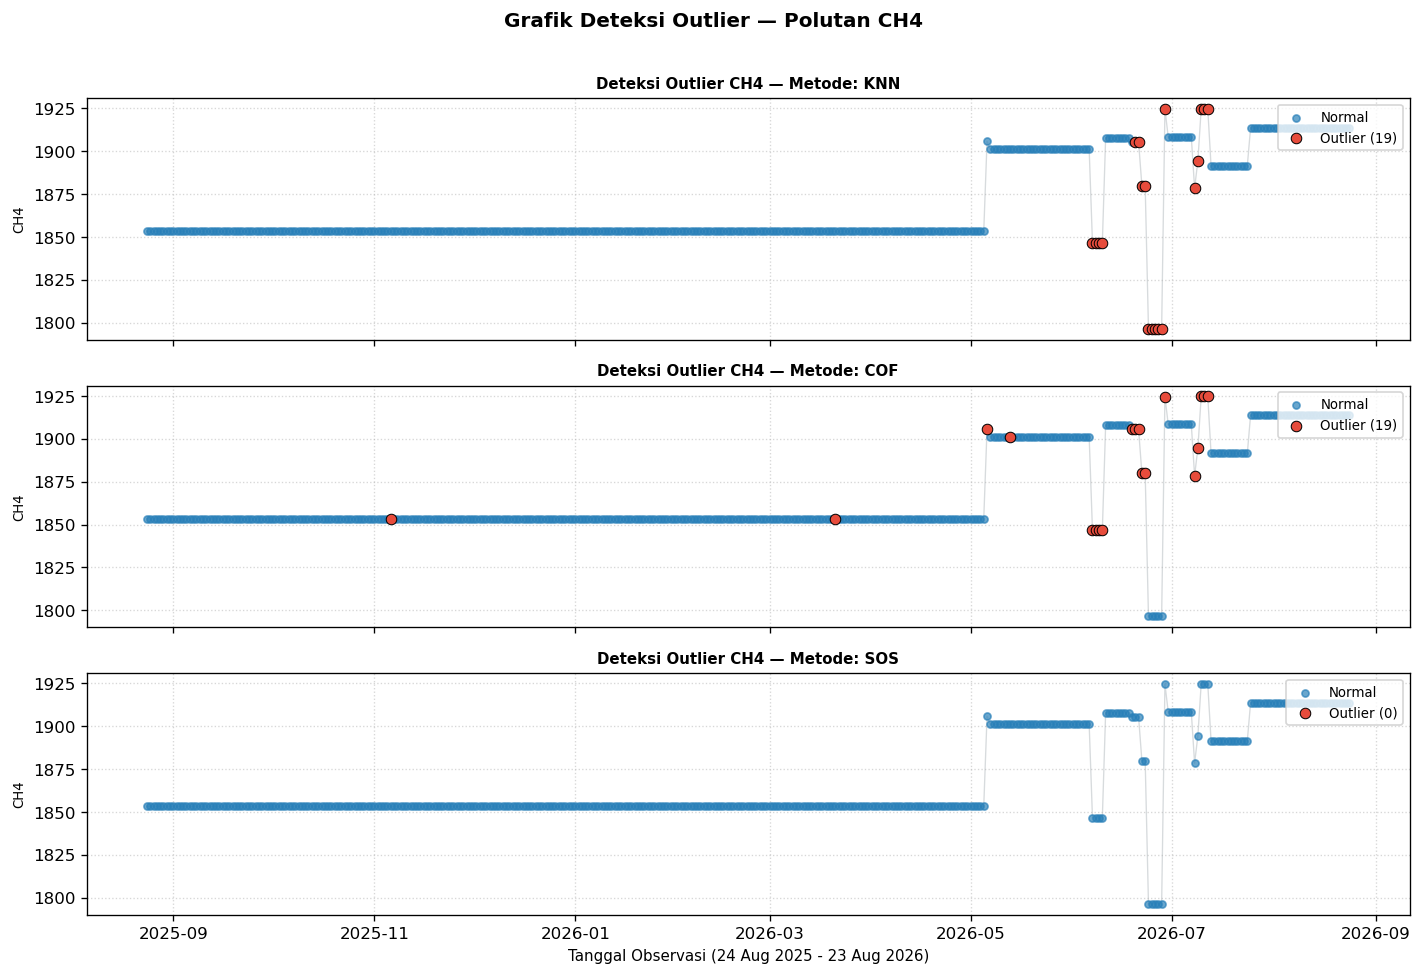

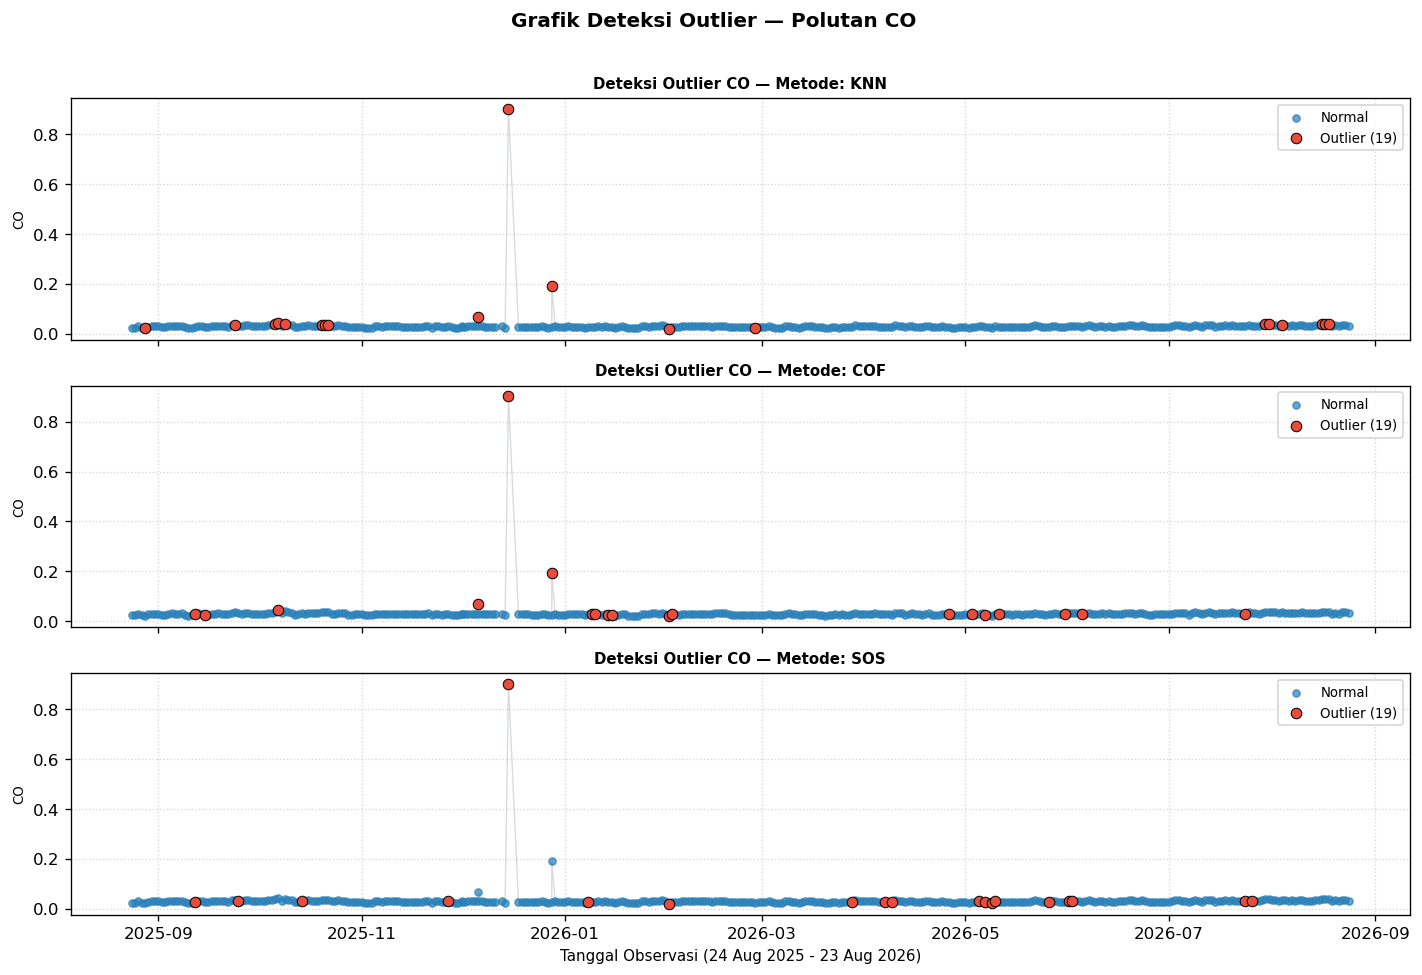

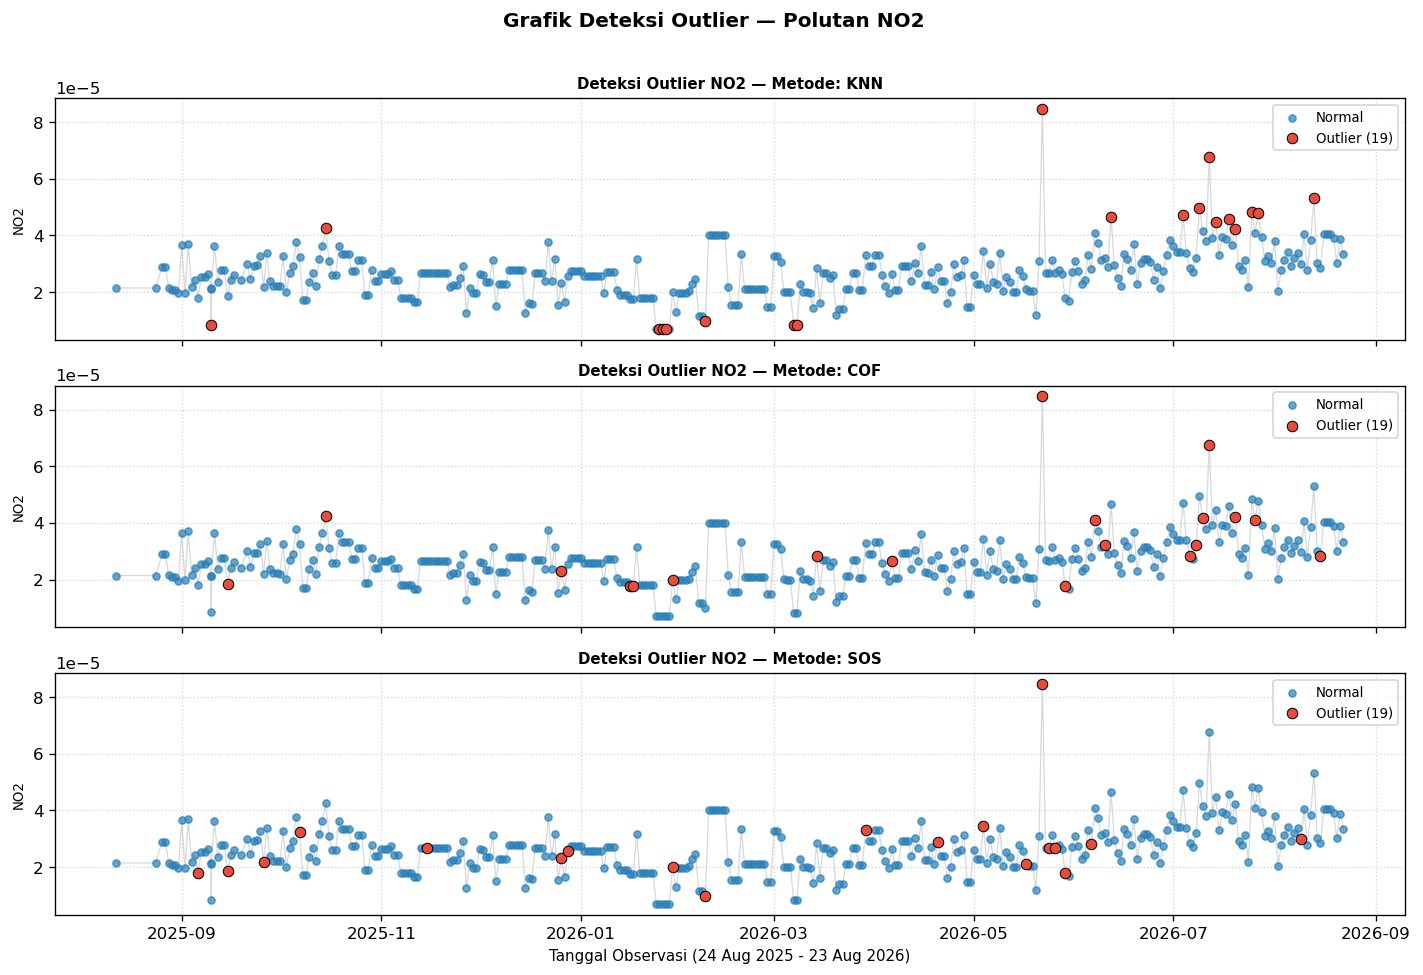

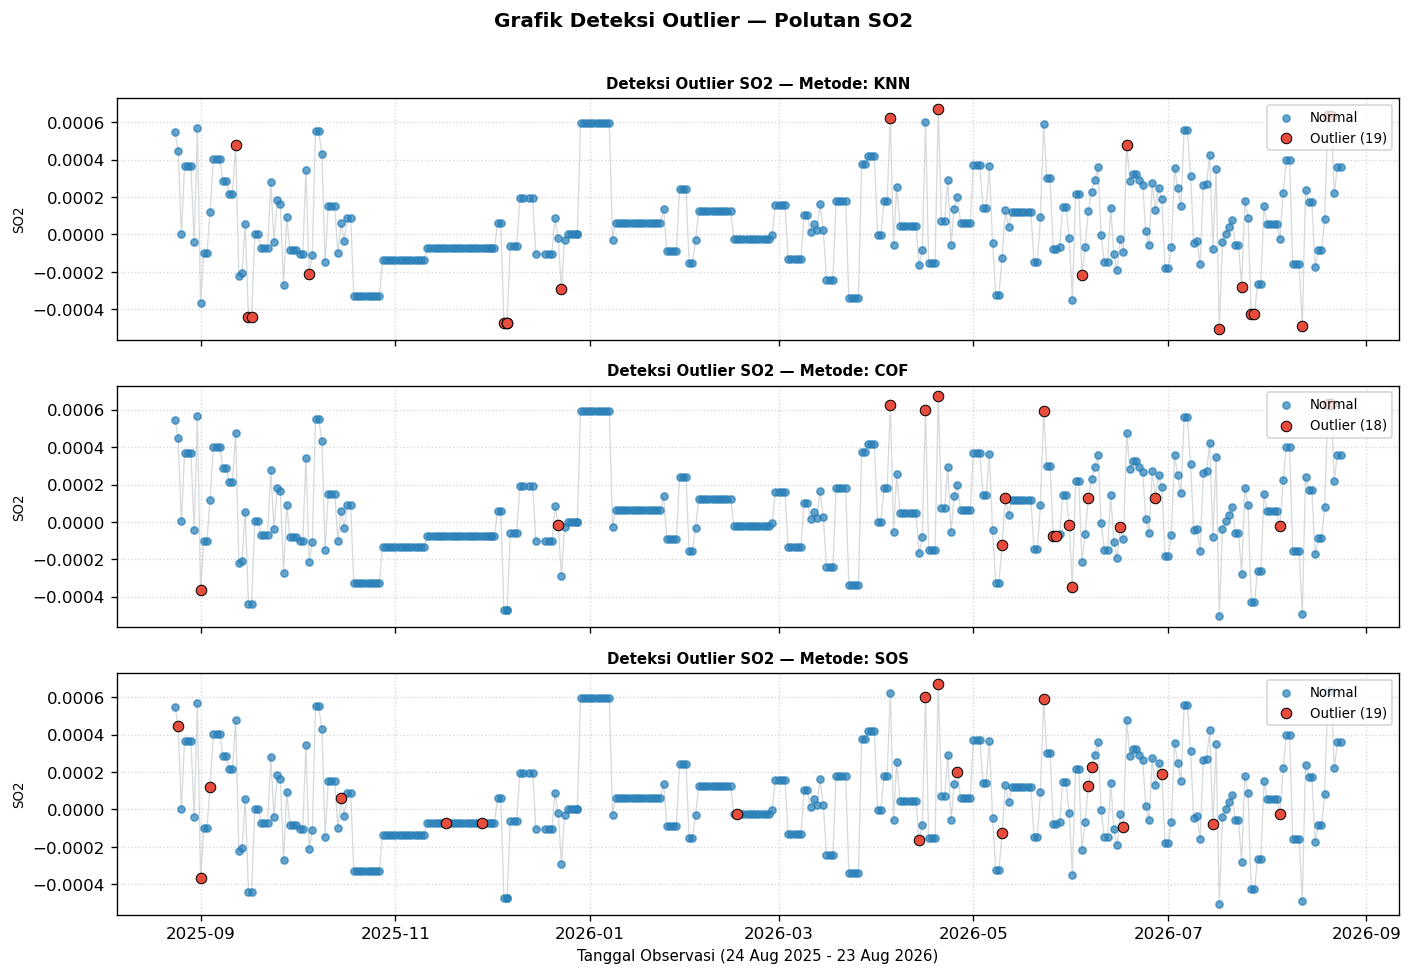

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from pyod.models.knn import KNN
from pyod.models.cof import COF
from pyod.models.sos import SOS

pollutants = ['CH4', 'CO', 'NO2', 'SO2']
contamination_rate = 0.05
np.random.seed(42)

# Visualisasi Subplot Metode Outlier untuk Setiap Polutan
for pol in pollutants:
    # 1. Cek path file dataset
    file_path = f"{pol}_lamongan_missing.csv" if os.path.exists(f"{pol}_lamongan_missing.csv") else f"data/{pol}_lamongan_missing.csv"
    df_p = pd.read_csv(file_path)
    df_p['date'] = pd.to_datetime(df_p['date'])
    df_valid_p = df_p.dropna(subset=[pol]).copy()
    
    # 2. Standarisasi + jitter mikroskopis agar COF & SOS bebas error pembagian nol
    raw_values = df_valid_p[[pol]].values.astype(float)
    jitter = np.random.normal(0, 1e-8, size=raw_values.shape)
    scaler = StandardScaler()
    X_p = scaler.fit_transform(raw_values + jitter)
    
    # 3. Model yang dipilih (KNN, COF, SOS)
    models_p = {
        'KNN': KNN(contamination=contamination_rate, n_neighbors=5, method='largest'),
        'COF': COF(contamination=contamination_rate, n_neighbors=10),
        'SOS': SOS(contamination=contamination_rate, perplexity=4.5)
    }
    
    # 4. Buat Subplot sesuai jumlah model (3 baris grafik per polutan)
    fig, axes = plt.subplots(len(models_p), 1, figsize=(12, 8), sharex=True, dpi=120)
    
    for i, (name, model) in enumerate(models_p.items()):
        model.fit(X_p)
        labels = model.labels_
        normal_m = df_valid_p[labels == 0]
        outliers_m = df_valid_p[labels == 1]
        
        ax = axes[i]
        # Garis abu-abu transparan
        ax.plot(df_valid_p['date'], df_valid_p[pol], color='#bdc3c7', linewidth=0.8, alpha=0.6, zorder=1)
        # Titik normal (biru)
        ax.scatter(normal_m['date'], normal_m[pol], color='#2980b9', s=18, alpha=0.7, label='Normal', zorder=2)
        # Titik outlier (merah dengan border hitam)
        ax.scatter(outliers_m['date'], outliers_m[pol], color='#e74c3c', s=40, edgecolors='black', linewidths=0.6, 
                   label=f'Outlier ({len(outliers_m)})', zorder=3)
        
        ax.set_title(f'Deteksi Outlier {pol} — Metode: {name}', fontsize=9, fontweight='bold')
        ax.set_ylabel(pol, fontsize=8)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.5)
        
    plt.xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=9)
    plt.suptitle(f'Grafik Deteksi Outlier — Polutan {pol}', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


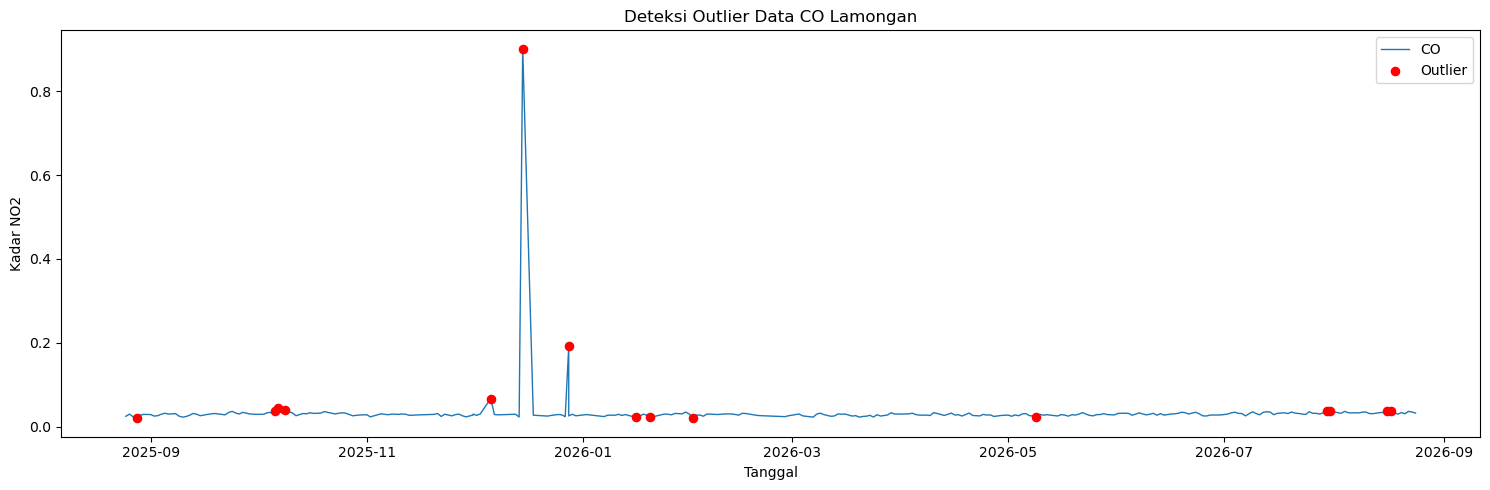

date     0
CO      76
dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "CO"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df_clean["outlier"] = model.fit_predict(
    df_clean[["CO"]]
)

# Memisahkan outlier
outliers = df_clean[df_clean["outlier"] == -1]

plt.figure(figsize=(15, 5))

plt.plot(
    df_clean["date"],
    df_clean["CO"],
    linewidth=1,
    label="CO"
)

plt.scatter(
    outliers["date"],
    outliers["CO"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data CO Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()
print(df.isnull().sum())


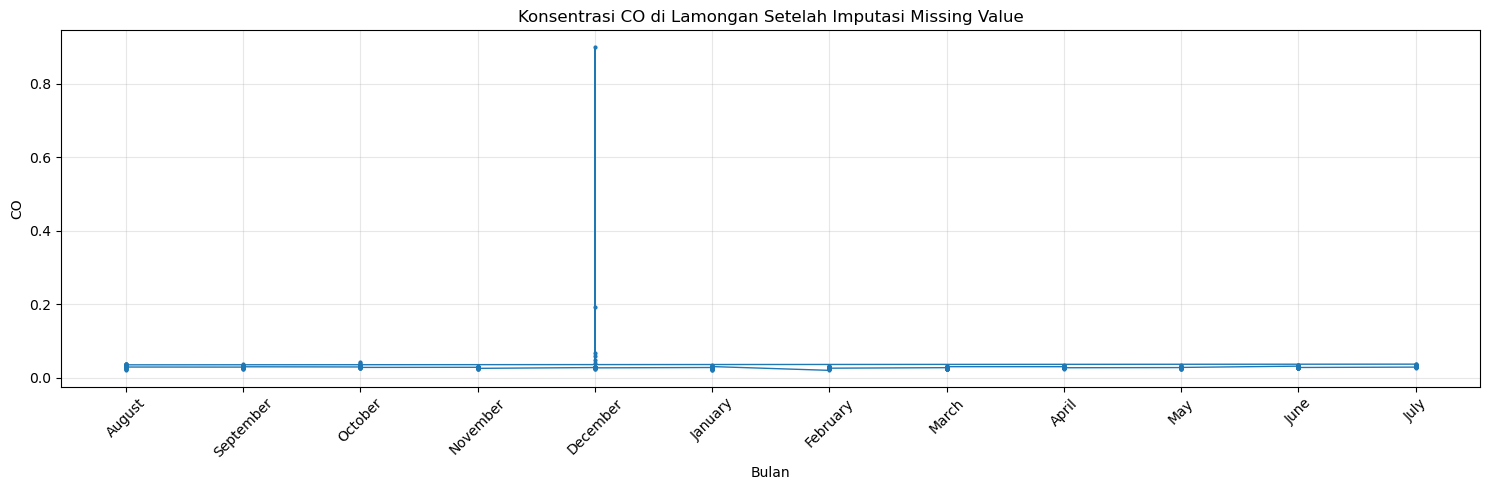


Missing value setelah imputasi:
0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data
df = pd.read_csv("CO_lamongan_sorted.csv")

# Mengubah date menjadi format tanggal
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Mengubah CO menjadi numerik
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Mengisi missing value
df["CO"] = df["CO"].interpolate(method="linear")
df["CO"] = df["CO"].ffill()
df["CO"] = df["CO"].bfill()

# Membuat kolom bulan
df["bulan"] = df["date"].dt.strftime("%B")

# Membuat grafik
plt.figure(figsize=(15, 5))

plt.plot(
    df["bulan"],
    df["CO"],
    marker="o",
    markersize=2,
    linewidth=1
)

plt.title("Konsentrasi CO di Lamongan Setelah Imputasi Missing Value")
plt.xlabel("Bulan")
plt.ylabel("CO")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMissing value setelah imputasi:")
print(df["CO"].isnull().sum())

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("CO_lamongan_sorted.csv")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Menghitung Q1 dan Q3
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan status data
df["status"] = df["CO"].apply(
    lambda x: "Outlier"
    if x < batas_bawah or x > batas_atas
    else "Normal"
)
outliers_iqr = df[df["status"] == "Outlier"]

print("\nJumlah data:")
print(df["status"].value_counts())

print("\nData Outlier:")
print(df[df["status"] == "Outlier"][["date", "CO"]])


Jumlah data:
status
Normal     356
Outlier     10
Name: count, dtype: int64

Data Outlier:
           date        CO
44   2025-10-07  0.043492
46   2025-10-09  0.039035
103  2025-12-04  0.039578
104  2025-12-05  0.048821
105  2025-12-06  0.058064
106  2025-12-06  0.067307
114  2025-12-15  0.901257
126  2025-12-28  0.191613
161  2026-02-01  0.020215
358  2026-08-17  0.038314


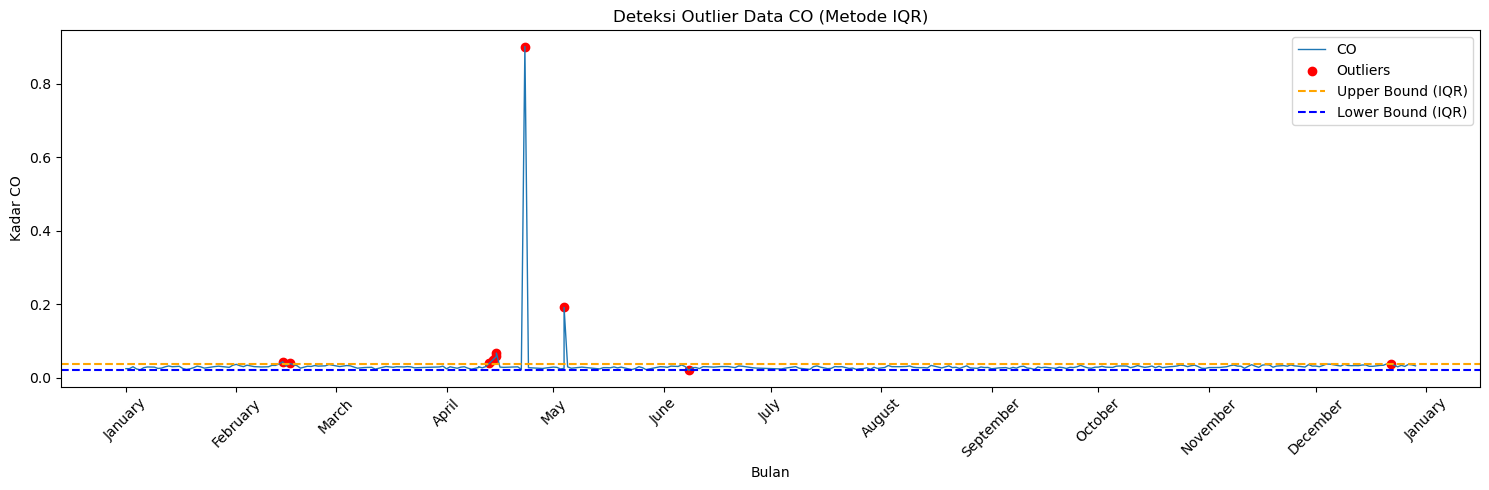

In [ ]:
plt.figure(figsize=(15, 5))

# Grafik CO
plt.plot(
    df["date"],
    df["CO"],
    label="CO",
    linewidth=1
)

# Titik outlier
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["CO"],
    color="red",
    marker="o",
    label="Outliers"
)

# Batas atas IQR
plt.axhline(
    batas_atas,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)"
)

# Batas bawah IQR
plt.axhline(
    batas_bawah,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)"
)

# Judul dan label
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Bulan")
plt.ylabel("Kadar CO")

# Menampilkan bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Membaca data
df = pd.read_csv("CO_lamongan_sorted.csv")

# Mengubah CO menjadi numerik
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# =========================
# DETEKSI OUTLIER DENGAN IQR
# =========================

Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan data outlier
outlier = (
    (df["CO"] < batas_bawah) |
    (df["CO"] > batas_atas)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

print("\nJumlah data sebelum penanganan:", len(df))
print("Jumlah outlier:", outlier.sum())

# =========================
# MENANGANI OUTLIER
# =========================

# Outlier diubah menjadi NaN
df.loc[outlier, "CO"] = None

# Mengisi nilai outlier dengan Linear Interpolation
df["CO"] = df["CO"].interpolate(method="linear")

# Menangani NaN jika berada di awal atau akhir data
df["CO"] = df["CO"].ffill().bfill()

print("\nJumlah missing setelah penanganan:",
      df["CO"].isna().sum())

print("Data setelah outlier ditangani:")
print(df.head(10))

df.to_csv("CO_lamongan_fix.csv", index=False)

print("\nFile berhasil disimpan sebagai:")
print("CO_lamongan_fix.csv")

Q1: 0.027159144723235225
Q3: 0.0315967946680206
IQR: 0.004437649944785377
Batas bawah: 0.02050266980605716
Batas atas: 0.03825326958519867

Jumlah data sebelum penanganan: 366
Jumlah outlier: 10

Jumlah missing setelah penanganan: 0
Data setelah outlier ditangani:
         date        CO
0  2025-08-24  0.024864
1  2025-08-25  0.024864
2  2025-08-26  0.030086
3  2025-08-27  0.024034
4  2025-08-28  0.021727
5  2025-08-29  0.027486
6  2025-08-30  0.029433
7  2025-08-31  0.029251
8  2025-09-01  0.029069
9  2025-09-02  0.025398

File berhasil disimpan sebagai:
CO_lamongan_fix.csv


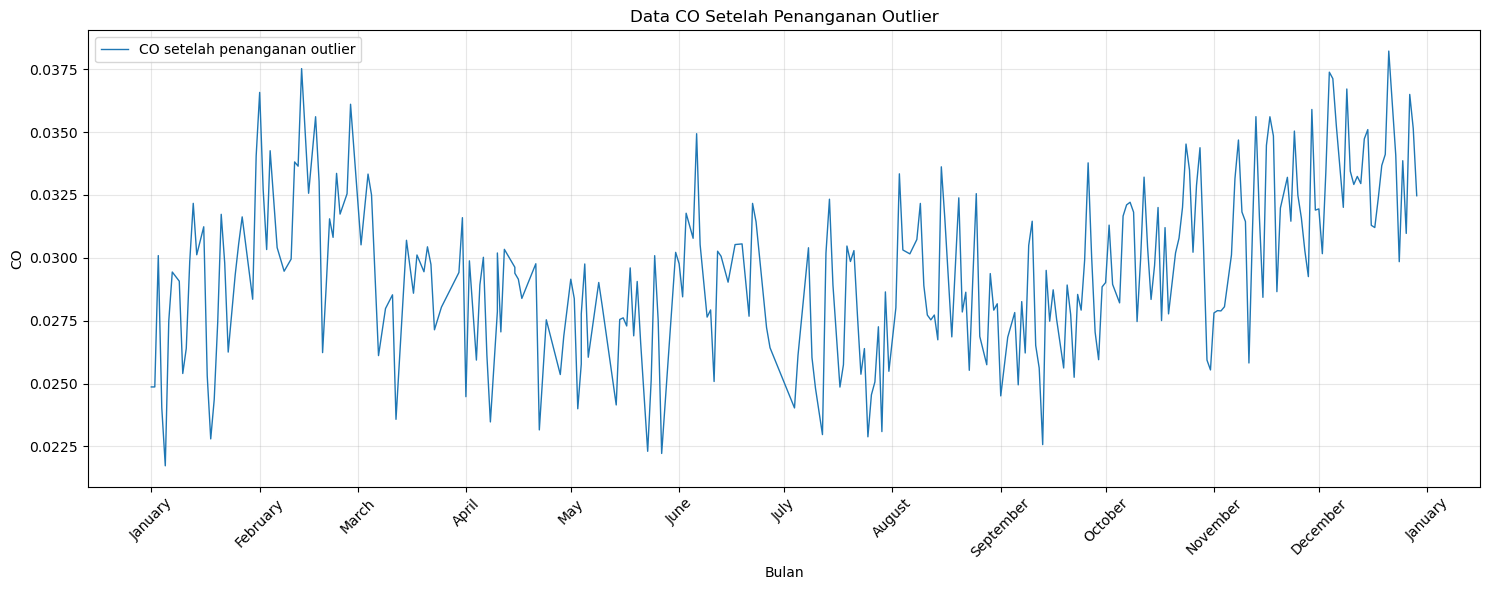

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

plt.plot(
    df["date"],
    df["CO"],
    linewidth=1,
    label="CO setelah penanganan outlier"
)

plt.title("Data CO Setelah Penanganan Outlier")
plt.xlabel("Bulan")
plt.ylabel("CO")

# Menampilkan nama bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("No2_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["NO2"] = pd.to_numeric(df["NO2"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "NO2"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["NO2"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["NO2"], linewidth=1, label="NO2")
plt.scatter(
    outliers["date"],
    outliers["NO2"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data NO2 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("So2_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["SO2"] = pd.to_numeric(df["SO2"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "SO2"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["SO2"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["SO2"], linewidth=1, label="SO2")
plt.scatter(
    outliers["date"],
    outliers["SO2"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data SO2 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("O3_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["O3"] = pd.to_numeric(df["O3"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "O3"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["O3"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["O3"], linewidth=1, label="O3")
plt.scatter(
    outliers["date"],
    outliers["O3"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data O3 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar O3")
plt.legend()
plt.tight_layout()
plt.show()